# K Nearest Neighbors (KNN) Theory

* Used for classification problems
* Using the example below, if we get new data (a new animal data point), we want to know if that new data point is a horse or a dog.
<div>
    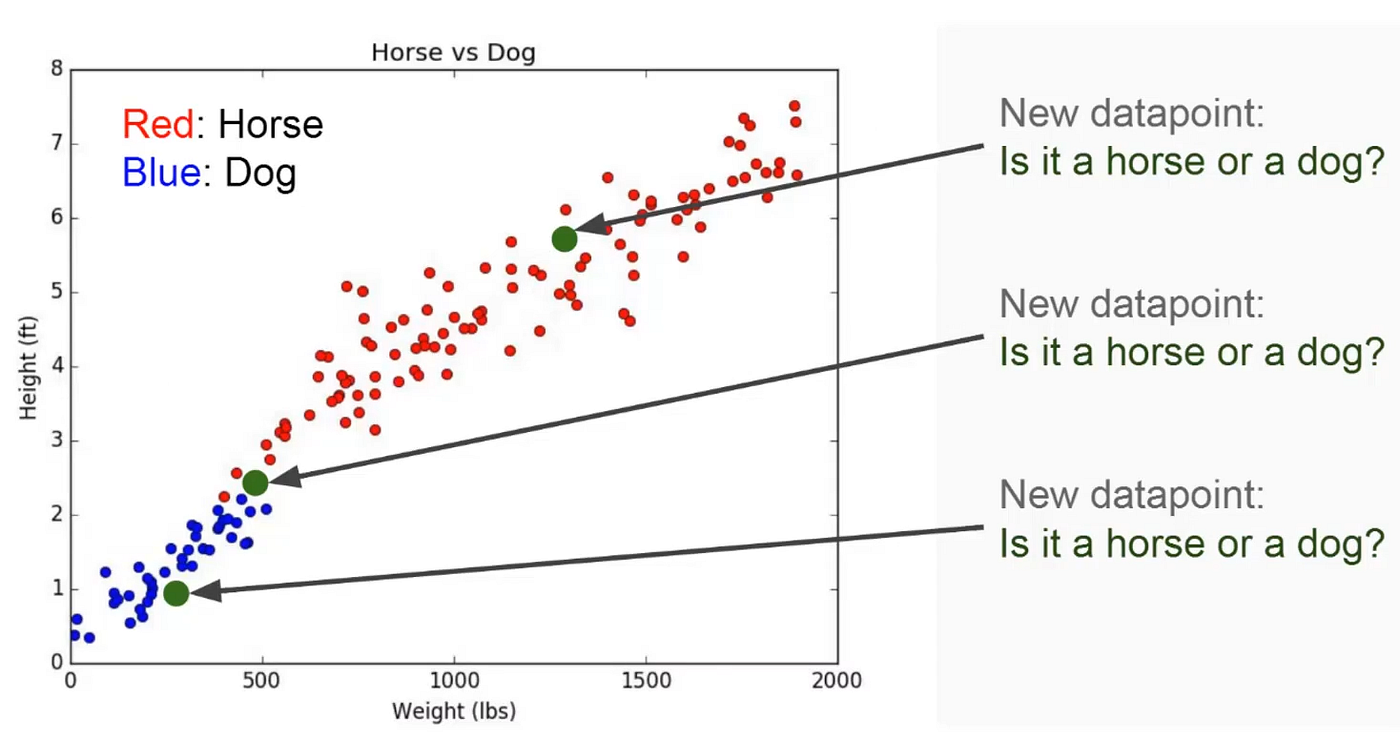
</div>

<b>Training Algorithm</b>
* Store all the data

<b>Prediction Algorithm</b>
* Calculate the distance from <i>x (a new data point)</i> to all points in your data
* Sort the points in your data by increasing distance from <i>x</i>
* Predict the majority label of the "k" closes points

<b>Additional Notes</b>
* Choosing a "K" will affect what class a new point is assigned to
* With example below, we want to predict if the question mark belongs to Class A or Class B
* If we choose K=3, then we will look at the three nearest neighbors to the new point. <br>
--In this case, we have two green and one red so we would predict it would classify as Class B. <br>
* With K=7, Class A would have more points that are closer to the new data
<div>
    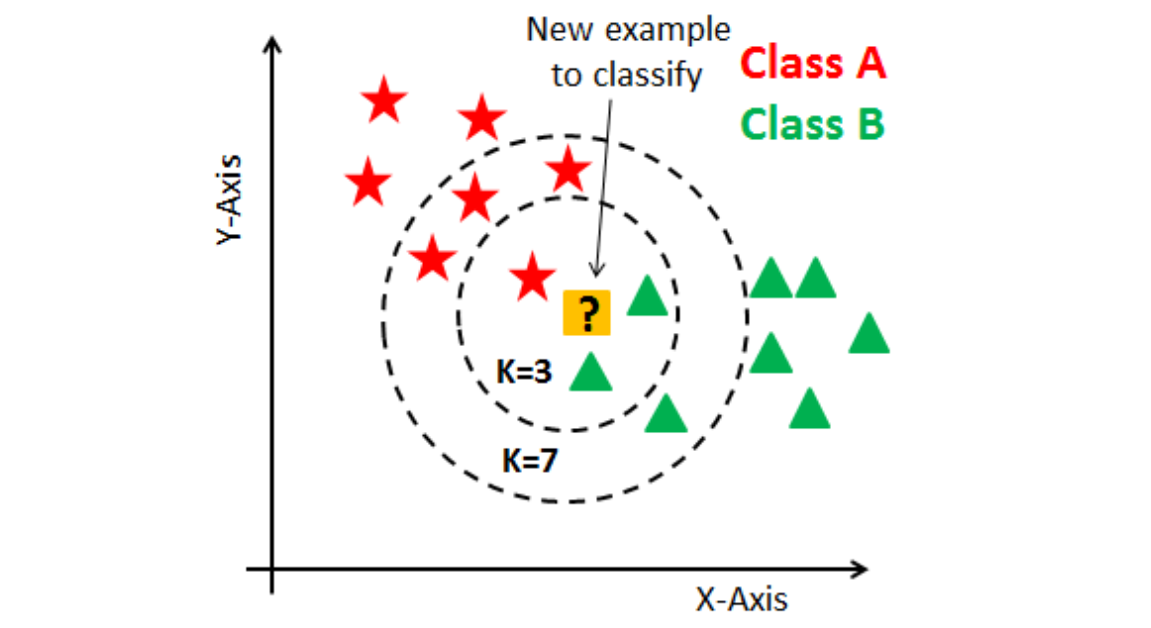
</div>
<br>
<br>
* As we increase our K values, we smooth out and create a bias (clean separation between the classes) in the model. 
* This runs the risk of mislabeling some points
<div>
    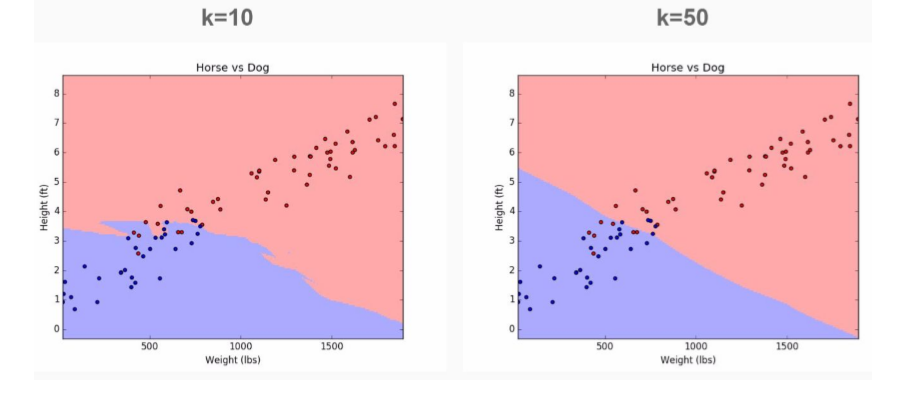
</div>

| ✅ Pros                     | ❌ Cons                    |
|----------------------------|----------------------------|
| Very simple               | High prediction cost (Worse for large data sets) |
| Training is trivial            | Not good with high dimensional data      |
| Works with any number of classes| Categorical features don't work well        |
| Easy to add more data| |
| Few Parameters (K, Distance Metric)| |

# KNN Model Building

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Anonymized data (we don't know what any of the columns or values represent, simulating a popular data science interview task)

In [2]:
df = pd.read_csv("Classified Data")
df

,Unnamed: 0,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,1.010953,1.034006,0.853116,0.622460,1.036610,0.586240,0.746811,0.319752,1.117340,1.348517,1
996,996,0.575529,0.955786,0.941835,0.792882,1.414277,1.269540,1.055928,0.713193,0.958684,1.663489,0
997,997,1.135470,0.982462,0.781905,0.916738,0.901031,0.884738,0.386802,0.389584,0.919191,1.385504,1
998,998,1.084894,0.861769,0.407158,0.665696,1.608612,0.943859,0.855806,1.061338,1.277456,1.188063,1


In [3]:
df.columns

Index(['Unnamed: 0', 'WTT', 'PTI', 'EQW', 'SBI', 'LQE', 'QWG', 'FDJ', 'PJF',
       'HQE', 'NXJ', 'TARGET CLASS'],
      dtype='object')

In [4]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1
...,...,...,...,...,...,...,...,...,...,...,...
995,1.010953,1.034006,0.853116,0.622460,1.036610,0.586240,0.746811,0.319752,1.117340,1.348517,1
996,0.575529,0.955786,0.941835,0.792882,1.414277,1.269540,1.055928,0.713193,0.958684,1.663489,0
997,1.135470,0.982462,0.781905,0.916738,0.901031,0.884738,0.386802,0.389584,0.919191,1.385504,1
998,1.084894,0.861769,0.407158,0.665696,1.608612,0.943859,0.855806,1.061338,1.277456,1.188063,1


* Any variable that is on a large scale will have a great effect on the distance between observations.
* Because of this, we are going to want to standardize everything so that it is all on the same scale
* Ultimately, this is because KNN depends on the distance between each feature or data point

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = df.drop('TARGET CLASS', axis=1)
y = df['TARGET CLASS']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
#Calculate mean and std from training data only to avoid leaking test info into the model
scaler = StandardScaler()
scaler.fit(X_train)  # learn scaling parameters from training data

StandardScaler()

In [10]:
#Use the fitted scaler to standardize both training and test data (same scale)
#Transform does a standardization by centering and scaling
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
#Produces an array of values (the scaled version of our actual original values from the df)
#Values in this example were originally very close to one another, but usually they won't be. 
#So it is a good idea to perform some sort of scaling transformation on the data
X_train_scaled

array([[-0.91009734, -0.40299513, -0.09136723, ..., -0.67763665,
        -1.4559778 ,  1.34470256],
       [-0.32968261,  0.44569652, -0.31578365, ..., -2.07678601,
        -1.11141383,  0.81290652],
       [-1.67830422,  0.85622787,  1.16388421, ..., -0.14680078,
         0.82474657, -0.6458806 ],
       ...,
       [ 1.23171194, -0.84532217, -0.59891035, ..., -1.24627877,
         1.28404654, -1.79866942],
       [-1.33949252,  0.9480828 , -1.72478987, ..., -1.14803035,
        -0.27062181, -0.96655497],
       [-1.33589347, -0.7429848 , -0.30460498, ..., -0.02371882,
        -0.81430966, -0.0575274 ]])

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
#Create and train the KNN model using the scaled training data
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=1)

In [14]:
predictions = knn.predict(X_test_scaled)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[151   8]
 [ 14 127]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       159
           1       0.94      0.90      0.92       141

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



### Elbow Method (choosing better value for K)

In [17]:
#Iterating many models with different K values.
#Plot their error rate to see which one has lowest error rate
error_rate = []

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test)) #Average error rate where predictions were not equal to actual test values

Text(0, 0.5, 'Error Rate')

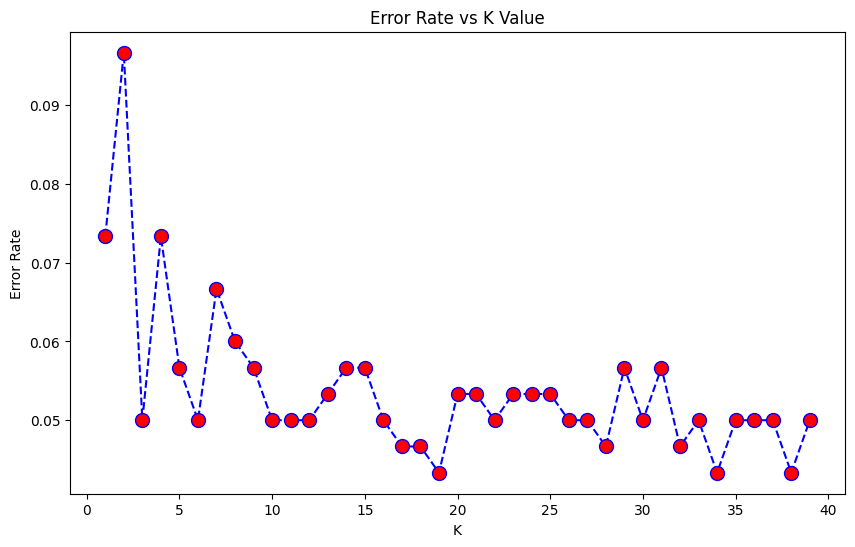

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed',marker='o', markerfacecolor='red', markersize=10)
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")

In [19]:
#Error rate starts at 1, enumerate starts at 0...Adjust enumerate function to get on same beginning postition
for k, err in enumerate(error_rate, start=1):
    print(f"K: {k} | Error Rate: {err}")

K: 1 | Error Rate: 0.07333333333333333
K: 2 | Error Rate: 0.09666666666666666
K: 3 | Error Rate: 0.05
K: 4 | Error Rate: 0.07333333333333333
K: 5 | Error Rate: 0.056666666666666664
K: 6 | Error Rate: 0.05
K: 7 | Error Rate: 0.06666666666666667
K: 8 | Error Rate: 0.06
K: 9 | Error Rate: 0.056666666666666664
K: 10 | Error Rate: 0.05
K: 11 | Error Rate: 0.05
K: 12 | Error Rate: 0.05
K: 13 | Error Rate: 0.05333333333333334
K: 14 | Error Rate: 0.056666666666666664
K: 15 | Error Rate: 0.056666666666666664
K: 16 | Error Rate: 0.05
K: 17 | Error Rate: 0.04666666666666667
K: 18 | Error Rate: 0.04666666666666667
K: 19 | Error Rate: 0.043333333333333335
K: 20 | Error Rate: 0.05333333333333334
K: 21 | Error Rate: 0.05333333333333334
K: 22 | Error Rate: 0.05
K: 23 | Error Rate: 0.05333333333333334
K: 24 | Error Rate: 0.05333333333333334
K: 25 | Error Rate: 0.05333333333333334
K: 26 | Error Rate: 0.05
K: 27 | Error Rate: 0.05
K: 28 | Error Rate: 0.04666666666666667
K: 29 | Error Rate: 0.056666666666

In [20]:
min_error = min(error_rate)
best_k = error_rate.index(min_error) + 1  # +1 because k starts at 1

print(f"\nBest K: {best_k} with lowest Error Rate: {min_error}")


Best K: 19 with lowest Error Rate: 0.043333333333333335


In [21]:
#Lowest K value is determined to be 19
#But we want to walk the line between a better fitting K, as well as a model that will have flexible decision boundaries for new data
#Choosing 17 since it still has a low error rate, but might lean itself to less overfitting (better generalization and model stability)
knn_bestK = KNeighborsClassifier(n_neighbors=17)
knn_bestK.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=17)

In [22]:
predictions = knn_bestK.predict(X_test_scaled)

In [23]:
print(confusion_matrix(y_test, predictions))

[[153   6]
 [  8 133]]


Interpretation:

* <b>True Negatives (TN)</b> = 153 Predicted class 0 and actually class 0
* <b>False Positives (FP)</b> = 6 Predicted class 1 but actually class 0
* <b>False Negatives (FN)</b> = 8 Predicted class 0 but actually class 1
* <b>True Positives: (TP)</b> = 133 Predicted class 1 and actually class 1

In [24]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       159
           1       0.96      0.94      0.95       141

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



<div style="display: inline-block; text-align: left">

|Metric|Class 0|Class 1|Explanation|
|:--------|:--------|:--------|:--------|
|Precision|	0.95|	0.96|	Out of all predicted as this class, % correct|
|Recall|	0.96|	0.94|	Out of all actual in this class, % correctly found|
|F1-score|	0.96|	0.95|	Harmonic mean of precision and recall (balance)|
|Support|	159|	141|	Number of true instances in each class|

</div>

This tradeoff (in our example, lower K value, but higher error rate than minimum error rate) is a classic bias-variance tradeoff:

* Lower K → lower bias but higher variance (overfitting).
* Higher K → higher bias but lower variance (more stable, less overfitting)